In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.utils import resample
import pingouin as pg

# 🧩 1️⃣ Prepare data

In [121]:
while True:
    try:
        DAYS_BACK = int(input("How many days of data do you want to analyze? (e.g. 30, 90, 180): "))
        if DAYS_BACK <= 0:
            raise ValueError
        break
    except ValueError:
        print("⚠️ You need to first download the data!")
    
FILE_NAME = f"./data/garmin_data_{DAYS_BACK}days/garmin_data_{DAYS_BACK}days.csv" 
df = pd.read_csv(FILE_NAME)

# ---- OUTPUT DIRECTORY ----
OUTPUT_DIR = f"./analysis/garmin_data_{DAYS_BACK}days"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\n📂 Data will be saved in: {OUTPUT_DIR}\n")


📂 Data will be saved in: ./analysis/garmin_data_180days



In [122]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

# Opcional: convertir columnas categóricas a numéricas
# Ejemplo: ciclo -> menstrual phases
df["cycle_phase"] = df["cycle_phase"].replace({"Ovulation": "Fertile"})
cycle_map = {"Menstrual": 1, "Follicular": 2, "Fertile": 3, "Luteal": 4}
df['cycle_phase_num'] = df['cycle_phase'].map(cycle_map)
df['cycle_phase'].value_counts()

cycle_phase
Luteal        60
Fertile       48
Follicular    43
Menstrual     30
Name: count, dtype: int64

# 📊 2️⃣ See averages per phase

Here we can see what the studies confirm, which is that during the follicular phase, the estrognes are higher, and therefore the hrv tends to be higher. Contrary, during the luteal phase, in which the progesteron is dominant, the hrv decreases.

NOTE: If one phase (e.g. Follicular) has 60 days and another (Menstrual) only 8, that’s fine for descriptive stats — but if you visualize it without showing sample sizes, it might be misleading because the uncertainty is not the same across phases. Therefore, it is useful to use weighted or annotated plots.

  cycle_phase  hrv_rmssd  resting_hr
0     Fertile  80.565217   43.145833
1  Follicular  84.547619   41.813953
2      Luteal  75.700000   44.700000
3   Menstrual  77.379310   42.500000


C:\Users\elsal\AppData\Local\Temp\ipykernel_40072\2703986251.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\elsal\AppData\Local\Temp\ipykernel_40072\2703986251.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


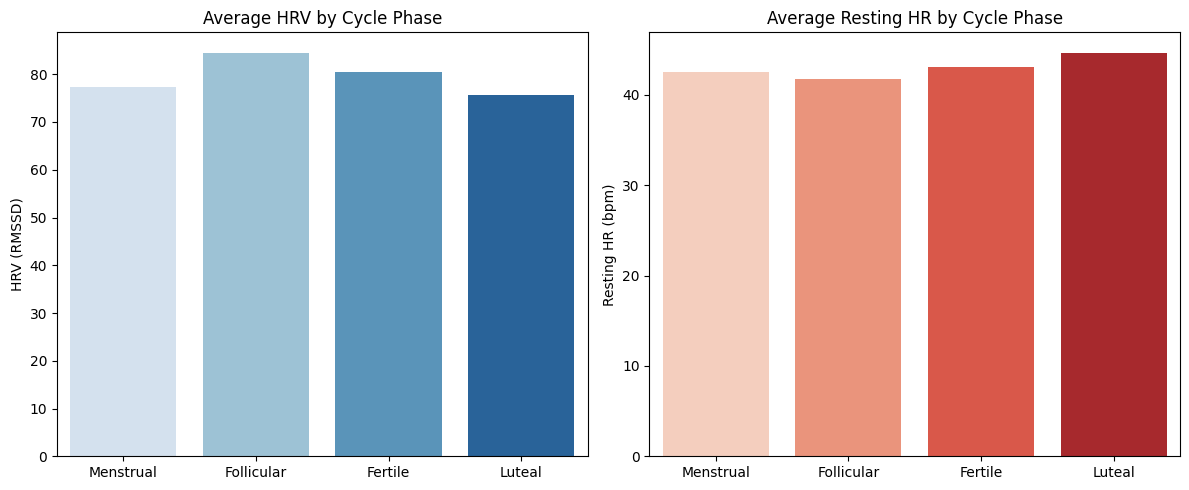

In [123]:
avg_by_phase = df.groupby("cycle_phase")[["hrv_rmssd", "resting_hr"]].mean().reset_index()
print(avg_by_phase)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Plot HRV
sns.barplot(
    data=avg_by_phase,
    x="cycle_phase", y="hrv_rmssd",
    order=cycle_map.keys(),
    ax=axes[0], palette="Blues"
)
axes[0].set_title("Average HRV by Cycle Phase")
axes[0].set_xlabel("")
axes[0].set_ylabel("HRV (RMSSD)")

# Plot Resting HR
sns.barplot(
    data=avg_by_phase,
    x="cycle_phase", y="resting_hr",
    order=cycle_map.keys(),
    ax=axes[1], palette="Reds"
)
axes[1].set_title("Average Resting HR by Cycle Phase")
axes[1].set_xlabel("")
axes[1].set_ylabel("Resting HR (bpm)")

plt.tight_layout()
plt.show()


#### Option A. Annotated plots

C:\Users\elsal\AppData\Local\Temp\ipykernel_40072\1439553358.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\elsal\AppData\Local\Temp\ipykernel_40072\1439553358.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


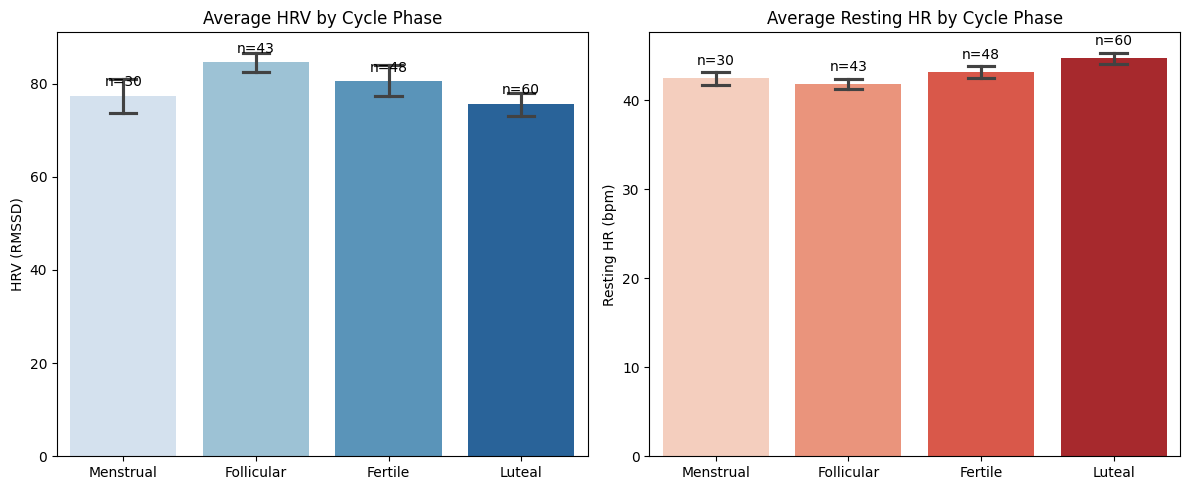

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["Menstrual", "Follicular", "Fertile", "Luteal"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Compute n per phase
n_per_phase = df["cycle_phase"].value_counts()

# --- Plot 1: HRV ---
sns.barplot(
    data=df, x="cycle_phase", y="hrv_rmssd",
    order=order, errorbar=('ci', 95), capsize=0.2,
    ax=axes[0], palette="Blues"
)
for i, phase in enumerate(order):
    n = n_per_phase.get(phase, 0)
    mean_val = df.loc[df["cycle_phase"] == phase, "hrv_rmssd"].mean()
    axes[0].text(i, mean_val + 2, f"n={n}", ha='center', fontsize=10)

axes[0].set_title("Average HRV by Cycle Phase")
axes[0].set_xlabel("")
axes[0].set_ylabel("HRV (RMSSD)")

# --- Plot 2: Resting HR ---
sns.barplot(
    data=df, x="cycle_phase", y="resting_hr",
    order=order, errorbar=('ci', 95), capsize=0.2,
    ax=axes[1], palette="Reds"
)
for i, phase in enumerate(order):
    n = n_per_phase.get(phase, 0)
    mean_val = df.loc[df["cycle_phase"] == phase, "resting_hr"].mean()
    axes[1].text(i, mean_val + 1.5, f"n={n}", ha='center', fontsize=10)

axes[1].set_title("Average Resting HR by Cycle Phase")
axes[1].set_xlabel("")
axes[1].set_ylabel("Resting HR (bpm)")

plt.tight_layout()
plt.show()


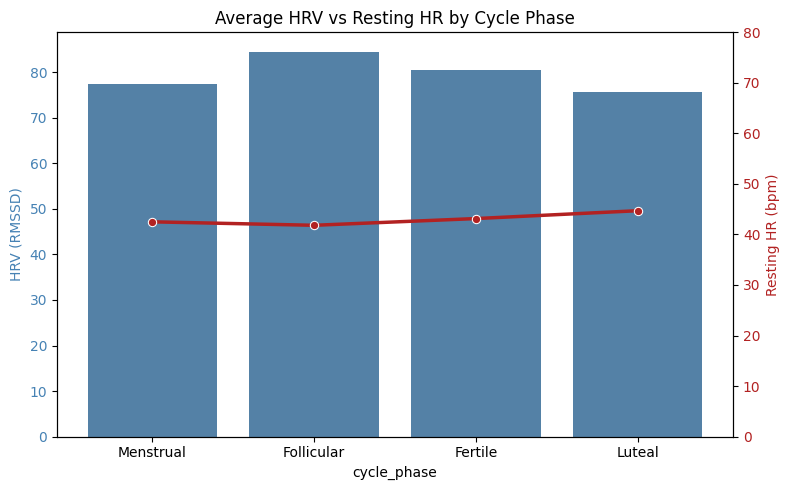

In [125]:
# Define the desired phase order
order = ["Menstrual", "Follicular", "Fertile", "Luteal"]

# Reorder avg_by_phase manually before plotting
avg_by_phase_ordered = avg_by_phase.set_index("cycle_phase").loc[order].reset_index()

fig, ax1 = plt.subplots(figsize=(8, 5))

# --- Bar plot for HRV (left y-axis) ---
sns.barplot(
    data=avg_by_phase_ordered,
    x="cycle_phase", y="hrv_rmssd",
    color="steelblue", ax=ax1
)
ax1.set_ylabel("HRV (RMSSD)", color="steelblue")
ax1.tick_params(axis='y', labelcolor="steelblue")
ax1.set_ylim(0, None)  # start from zero

# --- Line plot for Resting HR (right y-axis) ---
ax2 = ax1.twinx()
sns.lineplot(
    data=avg_by_phase_ordered,
    x="cycle_phase", y="resting_hr",
    color="firebrick", marker="o", linewidth=2.5, ax=ax2
)
ax2.set_ylabel("Resting HR (bpm)", color="firebrick")
ax2.tick_params(axis='y', labelcolor="firebrick")
ax2.set_ylim(0, 80)  # start from zero

plt.title("Average HRV vs Resting HR by Cycle Phase")
plt.tight_layout()
plt.show()


#### Option B. Balance the groups

C:\Users\elsal\AppData\Local\Temp\ipykernel_40072\1261445112.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: resample(x, replace=False, n_samples=min_n, random_state=42))
C:\Users\elsal\AppData\Local\Temp\ipykernel_40072\1261445112.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_by_phase_bal, x="cycle_phase", y="hrv_rmssd", order=order, ax=axes[0],palette="Blues")
C:\Users\elsal\AppData\Local\Temp\ipykernel_40072\1261445112.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

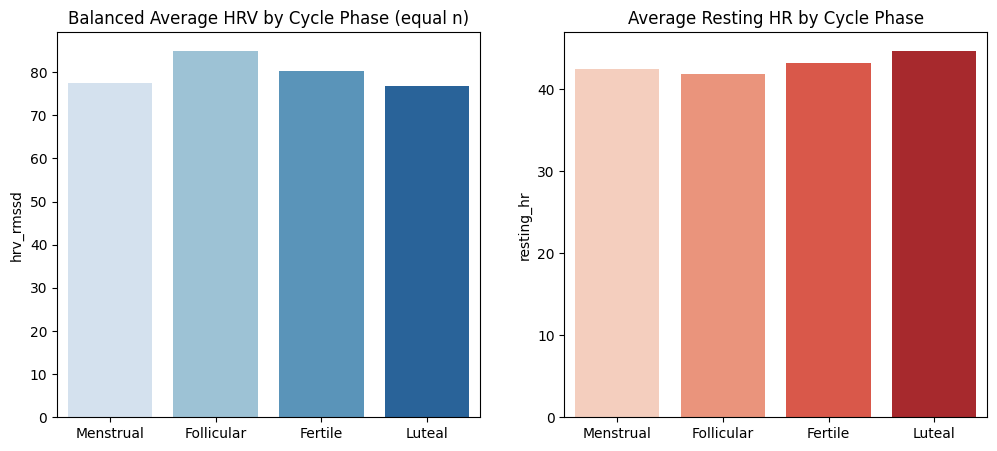

In [127]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

min_n = df["cycle_phase"].value_counts().min()
df_balanced = (
    df.groupby("cycle_phase", group_keys=False)
      .apply(lambda x: resample(x, replace=False, n_samples=min_n, random_state=42))
)
avg_by_phase_bal = df_balanced.groupby("cycle_phase")[["hrv_rmssd", "resting_hr"]].mean().reset_index()

sns.barplot(data=avg_by_phase_bal, x="cycle_phase", y="hrv_rmssd", order=order, ax=axes[0],palette="Blues")
axes[0].set_title("Balanced Average HRV by Cycle Phase (equal n)")
axes[0].set_xlabel("")


sns.barplot(data=avg_by_phase, x="cycle_phase", y="resting_hr", order=cycle_map.keys(), ax=axes[1],palette="Reds")
axes[1].set_title("Average Resting HR by Cycle Phase")
axes[1].set_xlabel("")
plt.show()


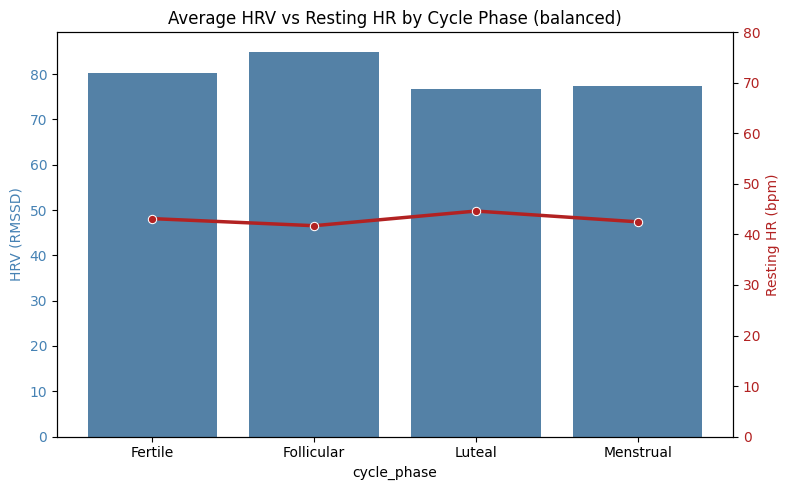

In [128]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# --- Bar plot for HRV (left y-axis) ---
sns.barplot(
    data=avg_by_phase_bal,
    x="cycle_phase", y="hrv_rmssd",
    color="steelblue", ax=ax1
)
ax1.set_ylabel("HRV (RMSSD)", color="steelblue")
ax1.tick_params(axis='y', labelcolor="steelblue")
ax1.set_ylim(0, None)  # start from zero

# --- Line plot for Resting HR (right y-axis) ---
ax2 = ax1.twinx()
sns.lineplot(
    data=avg_by_phase_bal,
    x="cycle_phase", y="resting_hr",
    color="firebrick", marker="o", linewidth=2.5, ax=ax2
)
ax2.set_ylabel("Resting HR (bpm)", color="firebrick")
ax2.tick_params(axis='y', labelcolor="firebrick")
ax2.set_ylim(0, 80)  # start from zero

plt.title("Average HRV vs Resting HR by Cycle Phase (balanced)")
plt.tight_layout()
plt.show()


# 📈 3️⃣ Numeric correlations

We need tests that provide correlations between numerical and categorical variables.

### 📉 Test ANOVA  (Analysis of Variance)

#### What it does

ANOVA tests whether at least one group mean is significantly different from the others.

Formally, it tests:
𝐻0:𝜇1 = 𝜇2 = 𝜇3 = ... = 𝜇𝑘  vs 𝐻1: At least one 𝜇𝑖 differs

In this case: 
- 𝐻0: average HRV is the same across all menstrual phases.
- 𝐻1: at least one phase has a different mean HRV.

#### What it assumes

- HRV values are normally distributed within each phase.
- The variances of HRV are roughly equal (homogeneity of variance).
- The observations are independent.

#### Why it’s useful

It tells you whether there’s any difference between phases — but it doesn’t tell you which ones differ.

In [91]:
groups = [df[df['cycle_phase'] == phase]['hrv_rmssd'].dropna() 
          for phase in df['cycle_phase'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA: F = {f_stat:.3f}, p = {p_val:.3e}")

ANOVA: F = 14.249, p = 1.327e-07


#### Interpretation:

Because the p-value is smaller than 0.05, we reject the null hipothesis. Therefore, HRV does differ between phases

### Welch ANOVA for imbalanced data

Regular ANOVA assumes homogeneity of variances and equal group sizes.

In [92]:
pg.welch_anova(dv='hrv_rmssd', between='cycle_phase', data=df)

,Source,ddof1,ddof2,F,p-unc,np2
0,cycle_phase,3,43.251219,19.754372,3.237587e-08,0.334618


#### Interpretation:

We tested whether mean HRV differs between cycle phases (Menstrual, Follicular, Fertile, Luteal). This test ignores other covariates and only looks at the group means, assuming independence between groups.

F(3, 43.25) = 19.75, p < 0.001, so the effect of phase on HRV is highly significant.

η² = 0.33, meaning about 33% of the variance in HRV is explained by phase — a large effect.


### 📉 Kruskal–Wallis Test


#### What it does

This is the non-parametric equivalent of ANOVA. It tests the same null hypothesis — “the distributions of HRV are the same across phases” — but without assuming normality or equal variances. It uses the ranks of the data, not the raw values.

#### Why it’s useful

Physiological data like HRV are often skewed, so Kruskal–Wallis is safer if the normality assumption doesn’t hold

In [93]:
h_stat, p_val = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H = {h_stat:.3f}, p = {p_val:.3e}")

Kruskal-Wallis: H = 32.093, p = 5.003e-07


### 📉 Post-hoc test (Dunn or Turkey)

#### Why we need it

ANOVA and Kruskal only say “there is some difference,” but not which pairs of groups differ.
A post-hoc test compares every pair of phases while controlling for multiple comparisons (so you don’t inflate Type I error).

#### Dunn’s test

The Dunn test is the non-parametric post-hoc that works with the Kruskal–Wallis output.
It tells you which phase pairs differ significantly.

In [94]:
import scikit_posthocs as sp
sp.posthoc_dunn(df, val_col='hrv_rmssd', group_col='cycle_phase', p_adjust='bonferroni')

,Fertile,Follicular,Luteal,Menstrual
Fertile,1.000000,0.092668,0.041343,0.128560
Follicular,0.092668,1.000000,0.000003,0.000098
Luteal,0.041343,0.000003,1.000000,1.000000
Menstrual,0.128560,0.000098,1.000000,1.000000


Because the groups are imbalanced we can use Games-Howell

In [95]:
pg.pairwise_gameshowell(dv='hrv_rmssd', between='cycle_phase', data=df)

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Fertile,Follicular,77.760000,85.421053,-7.661053,2.636358,-2.905923,40.749158,2.892292e-02,-0.817498
1,Fertile,Luteal,77.760000,70.366667,7.393333,2.653685,2.786063,45.839470,3.743680e-02,0.758642
2,Fertile,Menstrual,77.760000,70.066667,7.693333,2.828031,2.720385,37.427953,4.642380e-02,0.789831
3,Follicular,Luteal,85.421053,70.366667,15.054386,2.200885,6.840152,44.806368,1.063947e-07,1.866688
4,Follicular,Menstrual,85.421053,70.066667,15.354386,2.408237,6.375777,29.227208,3.186060e-06,2.166994
5,Luteal,Menstrual,70.366667,70.066667,0.300000,2.427194,0.123600,33.143938,9.993109e-01,0.036103


#### Interpretation:

We look at the diff value, the pval and the hedges (effect size). Low pval indicates correlation

HRV is significantly higher in the Follicular phase than in the Luteal and Menstrual phases. 
- Follicular-Menstrual: diff=15 (Follicular higher than menstrual, pval<0.001 so there is significant correlation, hedge=1.8 (big impact))

Fertile HRV lies in between, significantly lower than Follicular, but higher than Luteal/Menstrual.
- Fertile-Follicular: diff=-7.6 (Fertile lower than Follicular), pval=0.03, hedge=-0.81 (large)
- Fertile-Menstrual: diff=7.69 (Fertile higher than menstrual), pval0.04, hedge=0.78 (medium-large)

The pattern is Follicular > Fertile > Luteal ≈ Menstrual.

The effect sizes (Hedges g) show that these are not trivial differences — they are physiologically meaningful

#### Interpretation:

- Follicular vs Luteal: p = 0.000078  → significant
- Follicular vs Menstrual: p = 0.018  → significant

So:
- HRV in Follicular phase > HRV in Luteal and Menstrual phases.
- Others not significantly different.

### OLS Regression (Linear Model)

#### We want to answer:

💬 “Does HRV variation across the menstrual cycle remain significant after accounting for daily stress, training load, and recovery markers?”

That means we’re testing whether cycle phase still has explanatory power when we control for other factors that also affect HRV.

#### What it does

Ordinary Least Squares (OLS) regression lets you test how multiple predictors explain HRV simultaneously.

Your model:
- HRV =𝛽0 + 𝛽1(cycle phase) + 𝛽2(resting HR) + 𝛽3(stress) + 𝛽4(training load) + 𝛽5(sleep) + 𝜖 


#### What it tests

- Whether HRV differs by phase, after controlling for RHR, sleep, training load.
- Whether RHR predicts HRV.

#### Why it’s more powerful

It can separate direct hormonal effects (cycle) from physiological effects (RHR, stress, training load).

In [97]:
import statsmodels.formula.api as smf

df_no_nan = df.dropna(subset=["hrv_rmssd","cycle_phase","resting_hr", "avgStressLevel", "dailyTrainingLoadChronic", "sleep_score"])
phase_counts = df_no_nan["cycle_phase"].value_counts()
weights = df_no_nan["cycle_phase"].map(phase_counts).rdiv(1)

model = smf.ols(
    "hrv_rmssd ~ C(cycle_phase) + resting_hr + avgStressLevel + dailyTrainingLoadChronic + sleep_score",
    data=df_no_nan,
    weights=weights
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              hrv_rmssd   R-squared:                      -7.726
Model:                            OLS   Adj. R-squared:                 -8.480
Method:                 Least Squares   F-statistic:                    -10.25
Date:                Mon, 13 Oct 2025   Prob (F-statistic):               1.00
Time:                        09:55:30   Log-Likelihood:                -292.86
No. Observations:                  89   AIC:                             601.7
Df Residuals:                      81   BIC:                             621.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

C:\Users\elsal\AppData\Roaming\Python\Python312\site-packages\statsmodels\regression\linear_model.py:920: ValueWarning: Weights are not supported in OLS and will be ignoredAn exception will be raised in the next version.
  warnings.warn(msg, ValueWarning)
C:\Users\elsal\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:130: ValueWarning: unknown kwargs ['weights']
  warnings.warn(msg, ValueWarning)


<Axes: xlabel='cycle_phase', ylabel='hrv_rmssd'>

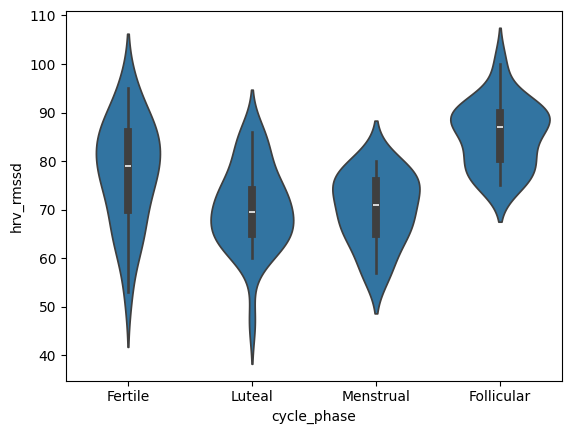

In [98]:
import seaborn as sns
sns.violinplot(data=df, x='cycle_phase', y='hrv_rmssd')

### Check for outliers and influencial points

In [102]:
from scipy.stats import zscore
df["z_hrv"] = zscore(df["hrv_rmssd"])
df_outliers_zscore = df[df["z_hrv"].abs() > 3]
print(df_outliers_zscore)

from scipy.stats import zscore
df["z_hrv"] = zscore(df["hrv_rmssd"])
df_outliers_iqr = df[df["z_hrv"].abs() > 3]
print(df_outliers_iqr)

Empty DataFrame
Columns: [date, hrv_rmssd, status, weekly_avg, lastnight_5min_high, feedback_phrase, resting_hr, total_sleep_hr, deep_sleep_hr, light_sleep_hr, rem_sleep_hr, awake_sleep_hr, avg_sleep_hr, avg_sleep_respiration, avg_sleep_stress, sleep_score, sleep_quality, sleep_feedback, sleep_need_baseline, sleep_need_actual, sleep_need_feedback, cycle_phase, maxStressLevel, avgStressLevel, charged, drained, monthlyLoadAerobicLow, monthlyLoadAerobicHigh, monthlyLoadAnaerobic, monthlyLoadAerobicLowTargetMin, monthlyLoadAerobicLowTargetMax, monthlyLoadAerobicHighTargetMin, monthlyLoadAerobicHighTargetMax, monthlyLoadAnaerobicTargetMin, monthlyLoadAnaerobicTargetMax, trainingBalanceFeedbackPhrase, trainingStatus, weeklyTrainingLoad, feedback, dailyTrainingLoadAcute, acwrPercent, acwrStatus, acwrStatusFeedback, dailyTrainingLoadChronic, minTrainingLoadChronic, maxTrainingLoadChronic, dailyAcuteChronicWorkloadRatio, baseline_lowUpper, baseline_balancedLow, baseline_balancedUpper, baseline_